In [27]:
import torch
import torch.nn as nn
from transformers import WhisperModel, WhisperFeatureExtractor
import librosa
import numpy as np
import pandas as pd
import os
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
import time
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [29]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CONFIGURATION
CONFIG = {
    "data_usage": "subset",  # "subset" (development) or "full" (final)
    "subset_ratio": 0.3,     # Use 30% of data for development
    "epochs": 2,             # Reduced epochs for faster iteration
    "batch_size": 4,         # Smaller batches for stability
    "max_audio_length": 10,  # Shorter audio clips (seconds)
    "enable_plots": True,    # Generate plots for report
    "save_results": True,    # Save metrics for comparison table
}

print("=== Configuration ===")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Using device: cpu
=== Configuration ===
  data_usage: subset
  subset_ratio: 0.3
  epochs: 2
  batch_size: 4
  max_audio_length: 10
  enable_plots: True
  save_results: True


In [31]:
class DysarthriaDataset(Dataset):
    def __init__(self, audio_paths, labels, feature_extractor, max_length=10):
        self.audio_paths = audio_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.max_length = max_length
        self.sampling_rate = 16000
    
    def __len__(self):
        return len(self.audio_paths)
    
    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = self.labels[idx]
        
        try:
            # Check if file exists
            if not os.path.exists(audio_path):
                raise FileNotFoundError(f"Audio file not found: {audio_path}")
        
            # Load and preprocess audio
            audio, sr = librosa.load(audio_path, sr=self.sampling_rate)
            
            # Trim or pad audio to max_length
            max_samples = self.max_length * self.sampling_rate
            if len(audio) > max_samples:
                audio = audio[:max_samples]
            else:
                audio = np.pad(audio, (0, max(0, max_samples - len(audio))))
            
            # Extract features
            inputs = self.feature_extractor(
                audio, 
                sampling_rate=self.sampling_rate,
                return_tensors="pt"
            )
            
            return {
                'input_features': inputs.input_features.squeeze(),
                'labels': torch.tensor(label, dtype=torch.long)
            }
            
        except Exception as e:
            print(f"Error loading {audio_path}: {e}")
            # Return zeros on error
            inputs = self.feature_extractor(
                np.zeros(self.sampling_rate * self.max_length),
                sampling_rate=self.sampling_rate,
                return_tensors="pt"
            )
            return {
                'input_features': inputs.input_features.squeeze(),
                'labels': torch.tensor(label, dtype=torch.long)
            }

In [32]:
class WhisperForAudioClassification(nn.Module):
    def __init__(self, num_classes=5, model_name="openai/whisper-tiny"):
        super().__init__()
        self.num_classes = num_classes
        self.model_name = model_name
        
        # Load Whisper model
        self.whisper = WhisperModel.from_pretrained(model_name)
        self.feature_extractor = WhisperFeatureExtractor.from_pretrained(model_name)
        
        # Freeze Whisper encoder for faster training
        for param in self.whisper.encoder.parameters():
            param.requires_grad = False
        
        # Get hidden size
        hidden_size = self.whisper.config.d_model
        
        # Efficient classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, input_features, labels=None):
        # Whisper encoder forward pass
        outputs = self.whisper.encoder(input_features)
        hidden_states = outputs.last_hidden_state
        
        # Global average pooling
        pooled_output = hidden_states.mean(dim=1)
        
        # Classification
        logits = self.classifier(pooled_output)
        
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
        
        return {'loss': loss, 'logits': logits}

In [33]:
def load_data_from_csv():
    """Load data and create proper splits since test data has no labels"""
    results_dir = 'results'
    train_csv = os.path.join(results_dir, 'train_data.csv')
    test_csv = os.path.join(results_dir, 'test_data.csv')
    
    if not os.path.exists(train_csv):
        print("Train CSV file not found")
        return None
    
    print("Loading data from CSV files...")
    train_df = pd.read_csv(train_csv)
    
    print(f"Train samples: {len(train_df)}")
    print(f"Train class distribution: {train_df['class'].value_counts().sort_index()}")
    
    # Use 'file_path' for audio
    audio_col = 'file_path'
    
    # Mapping function for classes 1-5
    def map_class_to_severity(class_label):
        class_num = int(float(class_label))
        return class_num - 1  # 1->0, 2->1, 3->2, 4->3, 5->4
    
    # Process training data
    y_train = train_df['class'].apply(map_class_to_severity).values
    X_train = train_df[audio_col].values
    
    # Apply subset if needed
    if CONFIG["data_usage"] == "subset":
        X_train, y_train = resample(X_train, y_train, 
                                  n_samples=int(len(X_train) * CONFIG["subset_ratio"]),
                                  random_state=42,
                                  stratify=y_train)
        print(f"After subset - Training samples: {len(X_train)}")
    
    # Split into train/val/test (60/20/20)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_train, y_train, test_size=0.4, random_state=42, stratify=y_train
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    print(f"Data split (60/20/20):")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Validation: {len(X_val)} samples") 
    print(f"  Testing: {len(X_test)} samples")
    
    print(f"Label distribution:")
    print(f"  Train: {np.bincount(y_train)}")
    print(f"  Val: {np.bincount(y_val)}")
    print(f"  Test: {np.bincount(y_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

In [34]:
def train_model(model, train_loader, val_loader):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
    
    epochs = CONFIG["epochs"]
    train_losses = []
    val_accuracies = []
    
    # Track total training time
    total_start_time = time.time()

    print(f"Training for {epochs} epochs")
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        total_loss = 0
        start_time = time.time()
        
        for batch_idx, batch in enumerate(train_loader):
            input_features = batch['input_features'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_features, labels=labels)
            loss = outputs['loss']
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            
            # Progress reporting
            if batch_idx % 10 == 0:
                progress = (batch_idx + 1) / len(train_loader) * 100
                print(f"  Progress: {progress:.1f}% | Loss: {loss.item():.4f}")
        
        epoch_time = time.time() - start_time
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Quick validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_features = batch['input_features'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_features)
                preds = torch.argmax(outputs['logits'], dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_accuracy = val_correct / val_total
        val_accuracies.append(val_accuracy)
        
        print(f"Epoch {epoch+1} Summary:")
        print(f"  Average Loss: {avg_loss:.4f}")
        print(f"  Validation Accuracy: {val_accuracy:.4f}")
        print(f"  Time: {epoch_time:.2f} seconds")
    
    # Calculate total training time
    total_training_time = time.time() - total_start_time
    print(f"Total training time: {total_training_time/60:.2f} minutes")
    
    return train_losses, val_accuracies

In [35]:
def predict_on_unlabeled_test(model):
    """Make predictions on the actual test data (no labels)"""
    results_dir = 'results'
    test_csv = os.path.join(results_dir, 'test_data.csv')
    
    if not os.path.exists(test_csv):
        print("Test CSV file not found")
        return
    
    test_df = pd.read_csv(test_csv)
    print(f"Making predictions on {len(test_df)} unlabeled test samples...")
    
    # Create dataset for unlabeled test data
    feature_extractor = model.feature_extractor
    test_dataset = DysarthriaDataset(test_df['file_path'].values, 
                                   np.zeros(len(test_df)),  # Dummy labels
                                   feature_extractor,
                                   max_length=CONFIG["max_audio_length"])
    
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
    
    # Make predictions
    model.eval()
    test_predictions = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_features = batch['input_features'].to(device)
            outputs = model(input_features)
            preds = torch.argmax(outputs['logits'], dim=1)
            test_predictions.extend(preds.cpu().numpy())
    
    # Convert back to original class labels (1-5)
    test_predictions_original = [pred + 1 for pred in test_predictions]
    
    # Save predictions
    results_df = pd.DataFrame({
        'file_path': test_df['file_path'],
        'predicted_class': test_predictions_original,
        'predicted_severity': [['Severe', 'Moderate', 'Mild', 'No dysarthria', 'Healthy'][p] for p in test_predictions]
    })
    
    results_df.to_csv('results/whisper_tiny_predictions.csv', index=False)
    print("Predictions saved to results/whisper_tiny_predictions.csv")
    
    return test_predictions

In [38]:
def main():
    try:
        # Load data from CSV files
        print("=== Loading Data from CSV Files ===")
        data = load_data_from_csv()
        if data is None:
            print("Failed to load data from CSV files")
            return None, 0, 0
        
        X_train, X_val, X_test, y_train, y_val, y_test = data
        
        # Initialize model
        print("\n=== Initializing Whisper-tiny Model ===")
        model = WhisperForAudioClassification(num_classes=5)
        feature_extractor = model.feature_extractor
        
        # Create datasets
        print("Creating datasets...")
        train_dataset = DysarthriaDataset(X_train, y_train, feature_extractor, 
                                        max_length=CONFIG["max_audio_length"])
        val_dataset = DysarthriaDataset(X_val, y_val, feature_extractor,
                                      max_length=CONFIG["max_audio_length"])
        test_dataset = DysarthriaDataset(X_test, y_test, feature_extractor,
                                       max_length=CONFIG["max_audio_length"])
        
        # Create data loaders
        batch_size = CONFIG["batch_size"]
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        
        print(f"Data loaders created:")
        print(f"  Training batches: {len(train_loader)}")
        print(f"  Validation batches: {len(val_loader)}")
        print(f"  Test batches: {len(test_loader)}")
        
        # Train model
        print("\n=== Starting Training ===")
        train_losses, val_accuracies = train_model(model, train_loader, val_loader)
        
        # Evaluate model
        print("\n=== Final Evaluation ===")
        model.eval()
        test_split_predictions = []
        test_true = []
        
        with torch.no_grad():
            for batch in test_loader:
                input_features = batch['input_features'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_features)
                preds = torch.argmax(outputs['logits'], dim=1)
                test_split_predictions.extend(preds.cpu().numpy())
                test_true.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(test_true, test_split_predictions)
        f1 = f1_score(test_true, test_split_predictions, average='macro')
        
        # predict on actual test data
        print("\n=== Predicting on Unlabeled Test Data ===")
        unlabeled_predictions = predict_on_unlabeled_test(model)

        if unlabeled_predictions is not None:
            print(f"Prediction distribution on actual test data: {np.bincount(unlabeled_predictions)}")

        # Results 
        print(f"\n" + "="*50)
        print("RESULTS - Whisper-tiny Baseline")
        print("="*50)
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test Macro F1: {f1:.4f}")

        # Classification report with proper 5-class handling
        print("\nClassification Report:")
        target_names = [
            'Severe (1→0)', 
            'Moderate (2→1)', 
            'Mild (3→2)', 
            'No dysarthria (4→3)', 
            'Healthy (5→4)'
        ]
        
        # Use all 5 classes expected for dysarthria severity
        print(classification_report(test_true, test_split_predictions, 
                                  labels=[0, 1, 2, 3, 4],
                                  target_names=target_names,
                                  zero_division=0))
        
        # Generate plots for report
        if CONFIG["enable_plots"]:
            os.makedirs('plots', exist_ok=True)
            
            # Confusion matrix for 5 classes
            plt.figure(figsize=(8, 6))
            cm = confusion_matrix(test_true, test_split_predictions, labels=[0, 1, 2, 3, 4])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                       xticklabels=target_names, 
                       yticklabels=target_names)
            plt.title('Confusion Matrix - Whisper-tiny')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.tight_layout()
            plt.savefig('plots/whisper_tiny_confusion_matrix.pdf', format='pdf', bbox_inches='tight')
            plt.show()
            
            # Training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses, 'b-', label='Training Loss')
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(val_accuracies, 'r-', label='Validation Accuracy')
            plt.title('Validation Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig('plots/whisper_tiny_training_history.pdf', format='pdf', bbox_inches='tight')
            plt.show()
        
        # Save results for comparison table
        if CONFIG["save_results"]:
            os.makedirs('results', exist_ok=True)
            
            results_df = pd.DataFrame({
                'Model': ['Whisper-tiny'],
                'Input_Features': ['Raw audio'],
                'Accuracy': [accuracy],
                'Macro_F1': [f1],
                'Train_Time_Minutes': [total_training_time/60],  # Actual time in minutes
                'Data_Usage': [CONFIG["data_usage"]],
                'Epochs': [CONFIG["epochs"]],
                'Batch_Size': [CONFIG["batch_size"]],
                'Notes': ['Baseline - CSV data loading']
            })
            
            results_df.to_csv('results/whisper_tiny_metrics.csv', index=False)
            print("Results saved to results/whisper_tiny_metrics.csv")
        
        return model, accuracy, f1
        
    except Exception as e:
        print(f"Error in main function: {e}")
        import traceback
        traceback.print_exc()
        return None, 0, 0


Starting Whisper-tiny Baseline
Loading data from: results/train_data.csv, results/test_data.csv
=== Loading Data from CSV Files ===
Loading data from CSV files...
Train samples: 2176
Train class distribution: class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64
After subset - Training samples: 652
Data split (60/20/20):
  Training: 391 samples
  Validation: 130 samples
  Testing: 131 samples
Label distribution:
  Train: [  9  37  82 109 154]
  Val: [ 3 13 27 36 51]
  Test: [ 2 12 28 37 52]

=== Initializing Whisper-tiny Model ===
Creating datasets...
Data loaders created:
  Training batches: 98
  Validation batches: 33
  Test batches: 33

=== Starting Training ===
Training for 2 epochs

Epoch 1/2
  Progress: 1.0% | Loss: 1.4471
  Progress: 11.2% | Loss: 1.4531
  Progress: 21.4% | Loss: 1.1967
  Progress: 31.6% | Loss: 1.2175
  Progress: 41.8% | Loss: 1.5996
  Progress: 52.0% | Loss: 2.0001
  Progress: 62.2% | Loss: 0.9461
  Progress: 72.4% | Loss: 1.5320
  Progr

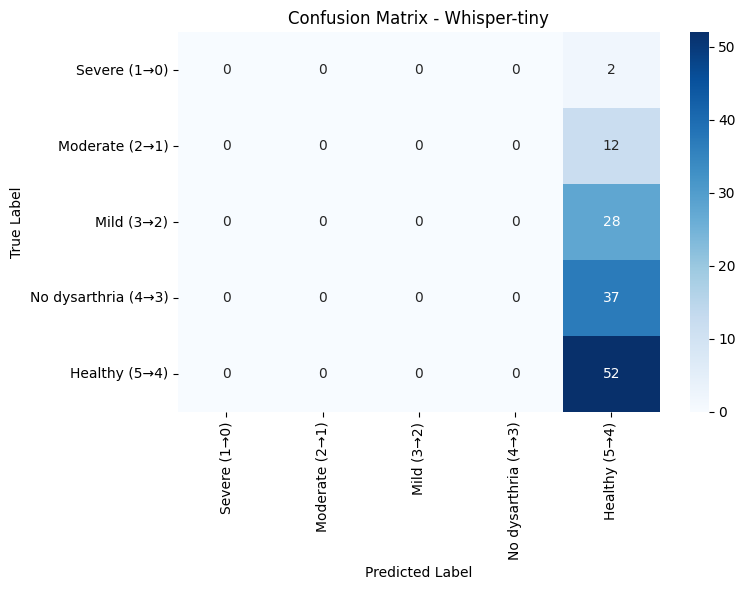

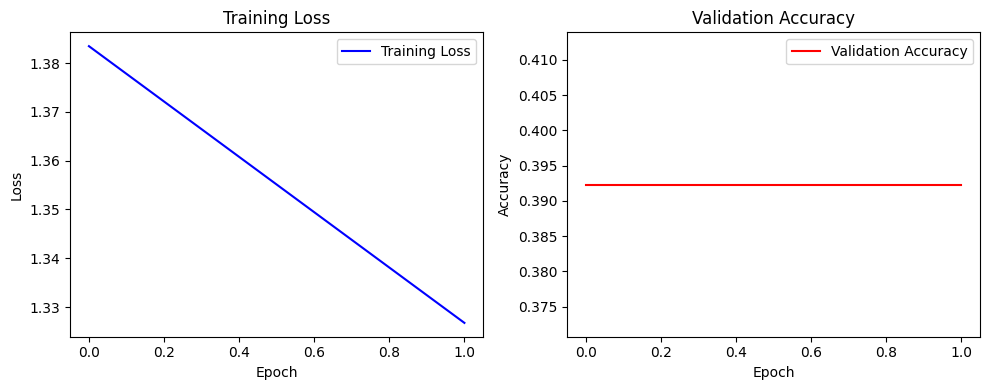

Error in main function: name 'total_training_time' is not defined

Baseline training failed


Traceback (most recent call last):
  File "C:\Users\m\AppData\Local\Temp\ipykernel_13452\978858393.py", line 136, in main
    'Train_Time_Minutes': [total_training_time/60],  # Actual time in minutes
                           ^^^^^^^^^^^^^^^^^^^
NameError: name 'total_training_time' is not defined


In [39]:
# EXECUTION
print("Starting Whisper-tiny Baseline")
print("Loading data from: results/train_data.csv, results/test_data.csv")

result = main()

if result[0] is not None:
    model, accuracy, f1 = result
    print(f"\nBASELINE COMPLETED!")
    print(f"Model: Whisper-tiny")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Plots saved to: plots/")
    print(f"Metrics saved to: results/whisper_tiny_metrics.csv")
else:
    print("\nBaseline training failed")